# Métodos hierárquicos de agrupamento - Prática

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

import scipy.cluster.hierarchy as shc

## 1) Repetindo o que fizemos em aula

Primeiramente vamos repetir o que fizemos em aula com a base de pinguins.

1. Selecione as variáveis quantitativas da base de pinguins
2. Elimine valores faltantes
3. Padronize as variáveis para média zero e desvio padrão 1
4. Faça um agrupamento hierárquico dividindo essa base em 3 grupos
5. Faça o Dendrograma

##### Carregando os dados e selecionando variáveis quatitativas

In [6]:
penguins = sns.load_dataset('penguins')
print(penguins.shape)
penguins.head()

(344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [7]:
# Quantitativas
peng_quan = penguins.select_dtypes('number')
peng_quan.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
3,NaN,NaN,NaN,NaN
4,36.7,19.3,193.0,3450.0


##### Verificando e removendo dados faltantes

In [9]:
peng_quan.isna().sum()

bill_length_mm       2
bill_depth_mm        2
flipper_length_mm    2
body_mass_g          2
dtype: int64

In [10]:
# removendo faltantes
peng_quan.dropna(inplace=True)

In [11]:
peng_quan.info()

<class 'pandas.core.frame.DataFrame'>
Index: 342 entries, 0 to 343
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   bill_length_mm     342 non-null    float64
 1   bill_depth_mm      342 non-null    float64
 2   flipper_length_mm  342 non-null    float64
 3   body_mass_g        342 non-null    float64
dtypes: float64(4)
memory usage: 13.4 KB


##### Padronizando o banco de dados

In [13]:
# gerando padronizador
padronizador = StandardScaler()

# Padronizando dados quantitativos
peng_pad = padronizador.fit_transform(peng_quan)
peng_pad

array([[-0.88449874,  0.78544923, -1.41834665, -0.56414208],
       [-0.81112573,  0.1261879 , -1.06225022, -0.50170305],
       [-0.66437972,  0.43046236, -0.42127665, -1.18853234],
       ...,
       [ 1.18828874, -0.73592307,  1.50164406,  1.93341896],
       [ 0.23443963, -1.19233476,  0.7894512 ,  1.24658968],
       [ 1.09657248, -0.53307343,  0.86067049,  1.49634578]])

In [14]:
# Gerando um dataframe com os dados padronizados

peng_pad = pd.DataFrame(peng_pad, columns=peng_quan.columns)
peng_pad.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,-0.884499,0.785449,-1.418347,-0.564142
1,-0.811126,0.126188,-1.062250,-0.501703
2,-0.664380,0.430462,-0.421277,-1.188532
3,-1.324737,1.089724,-0.563715,-0.938776
4,-0.847812,1.748985,-0.777373,-0.689020


##### Criando um agrupamento hierárquico

In [16]:
# Definindo o objeto
agrupamento = AgglomerativeClustering(
    n_clusters = 3,
    linkage = 'complete'    
)
agrupamento

AgglomerativeClustering(linkage='complete', n_clusters=3)

In [17]:
# Treinando o modelo/algoritmo

agrupamento.fit(peng_pad)

AgglomerativeClustering(linkage='complete', n_clusters=3)

In [18]:
agrupamento.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2,
       1, 2, 1, 2, 2, 1, 2, 1, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 1, 2, 2,
       2, 2, 2, 1, 2, 1, 2, 1, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 1, 2, 2, 2, 2, 1, 2, 2, 2, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,agrupamento
0,-0.884499,0.785449,-1.418347,-0.564142,1
1,-0.811126,0.126188,-1.062250,-0.501703,1
2,-0.664380,0.430462,-0.421277,-1.188532,1
3,-1.324737,1.089724,-0.563715,-0.938776,1
4,-0.847812,1.748985,-0.777373,-0.689020,1


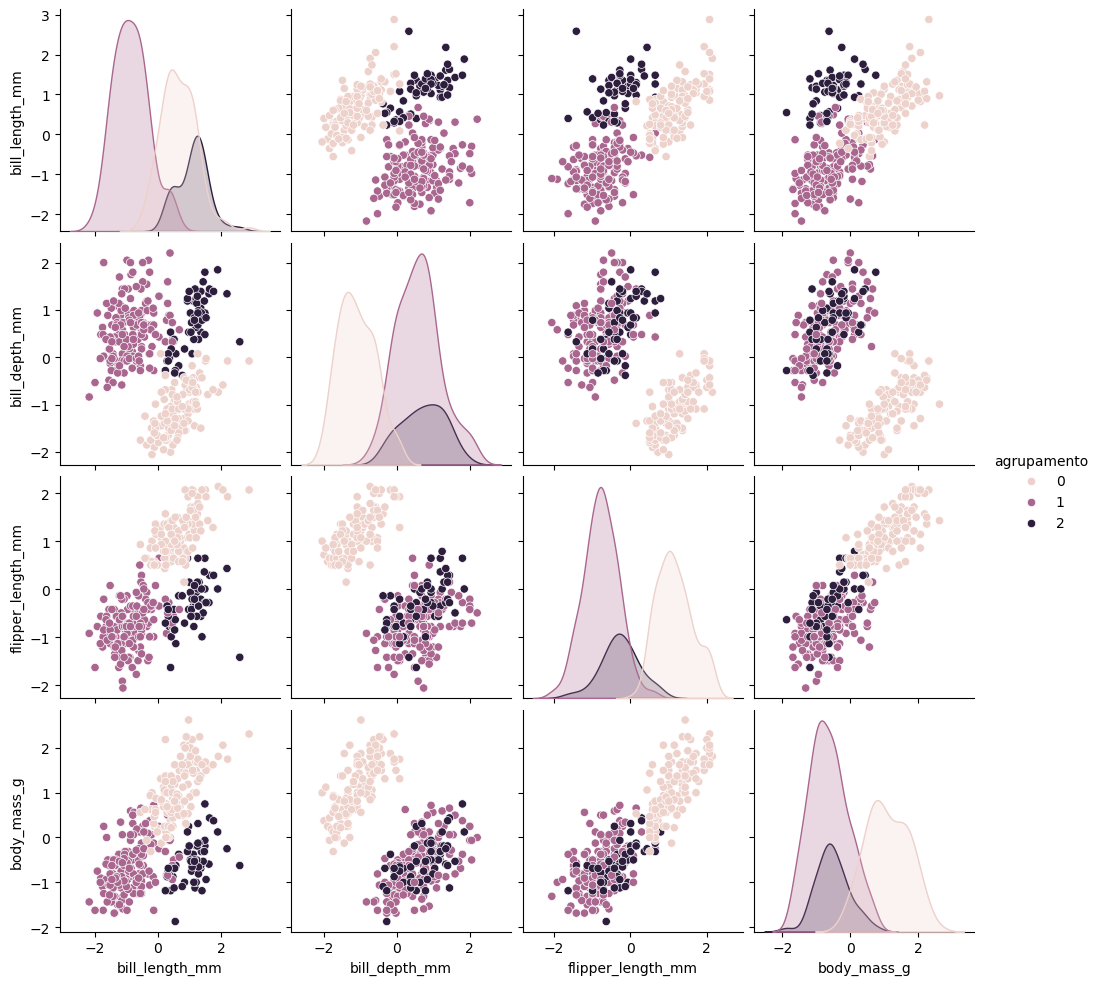

In [19]:
# mesmo não sendo a ideia façamos um pairplot em função dos grupos

# ajustando o dataframe
peng_pad['agrupamento'] = agrupamento.labels_

# Plot
sns.pairplot(peng_pad, hue='agrupamento')

peng_pad.head()

##### Dendrograma para os dados

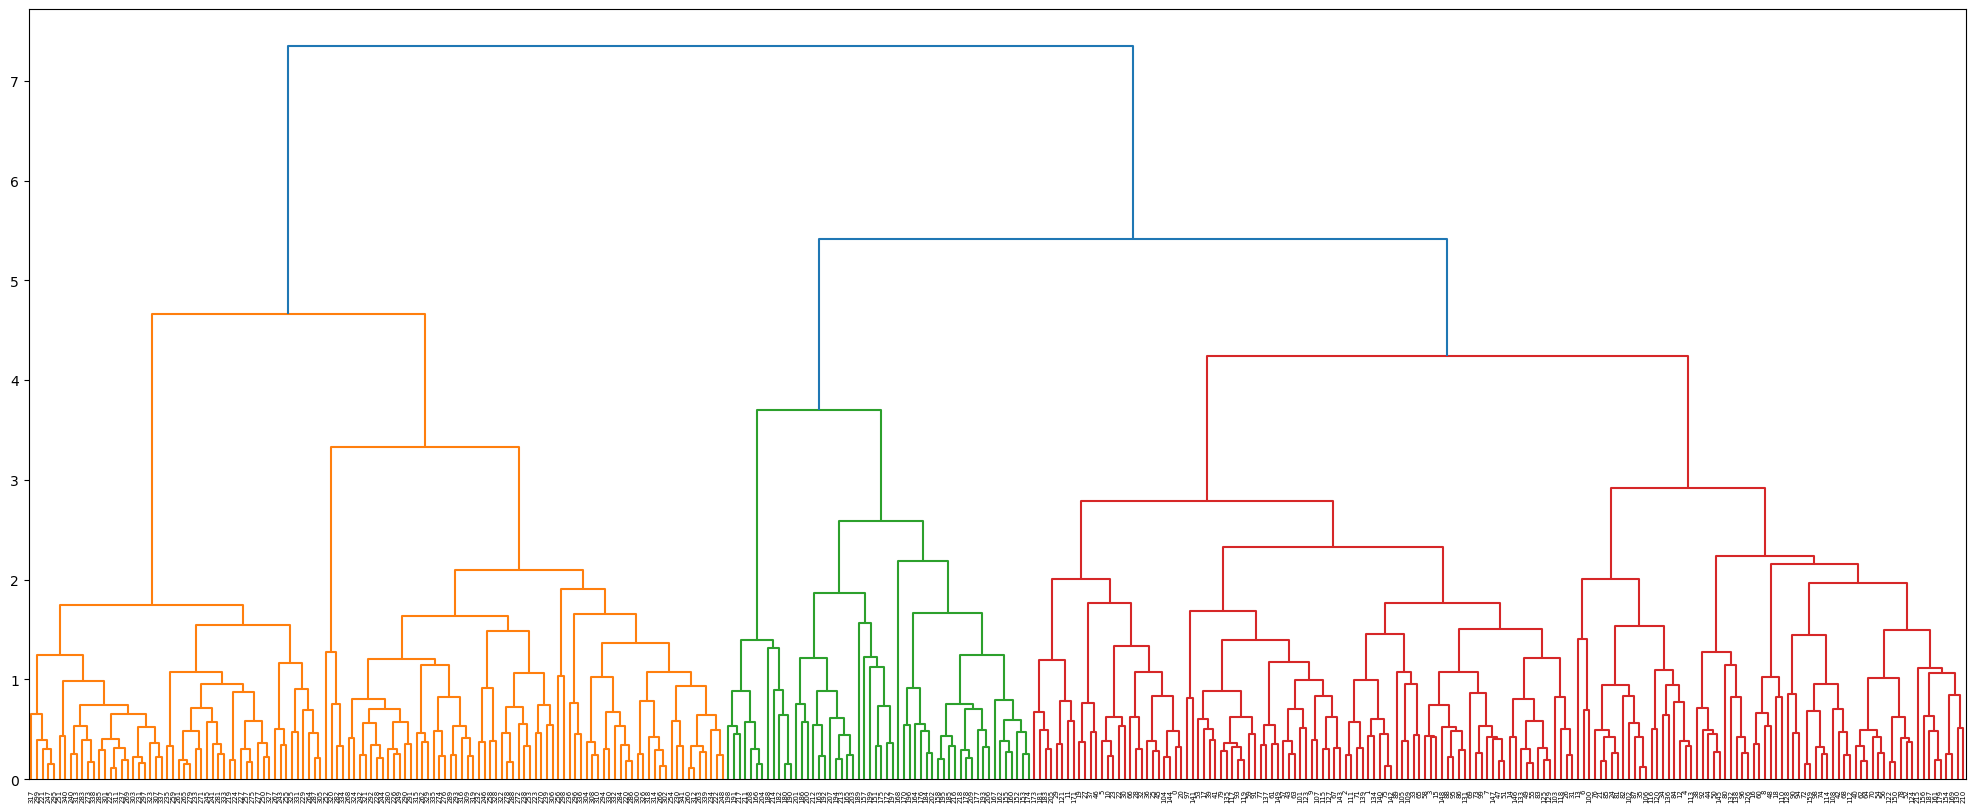

In [21]:
plt.figure(figsize=[25,10])
dendrograma = shc.dendrogram(shc.linkage(peng_pad, method='complete'))
plt.savefig('practice_dendrogam.png', dpi=200)

## 2) Avalie os grupos

Descreva os grupos:

- Quantos pinguins de cada espécie há em cada grupo?
- Descreva as variáveis quantitativas de cada grupo com as técnicas que você preferir.

In [23]:
# Definindo o index como id do pinguim
penguins.index.name = 'id_peng'
peng_pad.index.name = 'id_peng'

# Fazendo um merge do banco de dados com os dados dos grupos gerados
penguins = penguins.merge(peng_pad['agrupamento'], how='left', on='id_peng')

In [24]:
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,agrupamento
id_peng,,,,,,,,
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male,1.0
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female,1.0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female,1.0
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,1.0
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female,1.0


In [25]:
# fazendo um crosstab para verificar a distribuição das espécies no grupos gerados

pd.crosstab(penguins.species, penguins.agrupamento)

agrupamento,0.0,1.0,2.0
species,,,
Adelie,0,151,1
Chinstrap,1,14,53
Gentoo,122,0,0


Vemos que o grupo 0 descreve muito bem a espécie `Gentoo`. Já os grupos 1 e 2, apesar de descreverem bem as demais espécies, têm seus dados misturados, particularmente para a espécie `Chinstrap`.

##### Verificando as quantitativas em função dos grupos

- Utilizando `boxplot` e `pairplot`

In [28]:
# Definindo uma função para o boxplot

def plot_box(varx):
    fig, ax = plt.subplots(figsize=[10,5])
    ax = sns.boxplot(data=penguins, y='agrupamento', x=varx, hue='agrupamento', orient='h')
    plt.show()

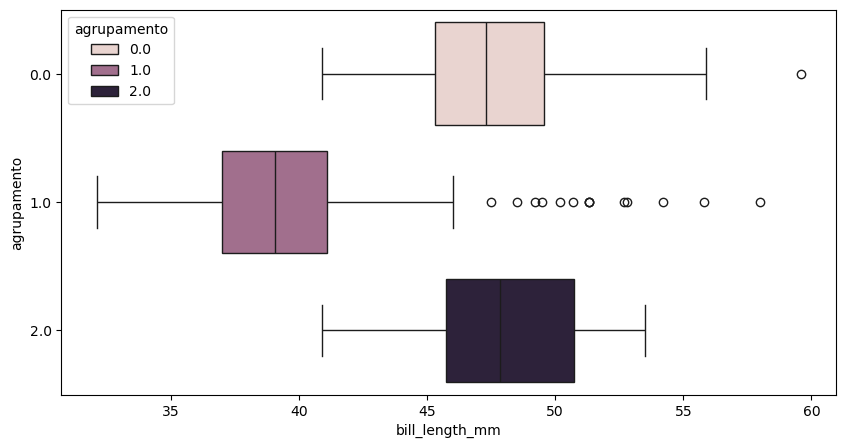

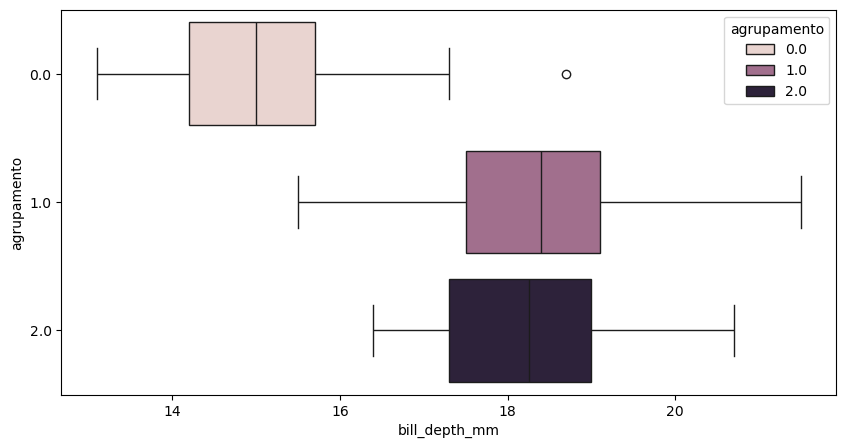

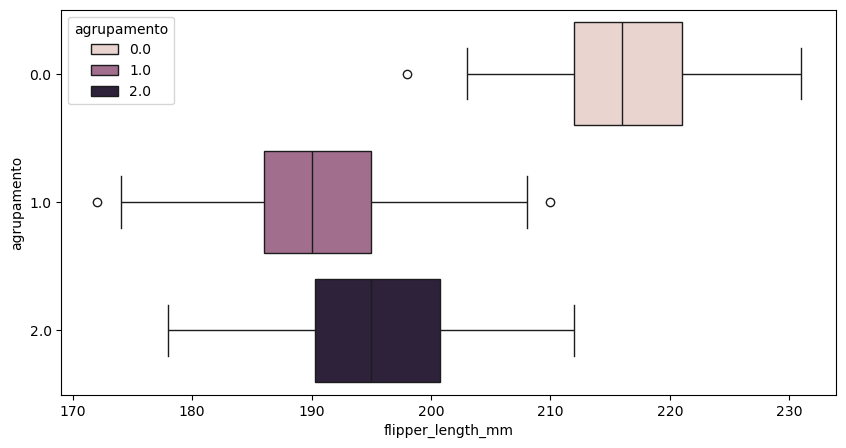

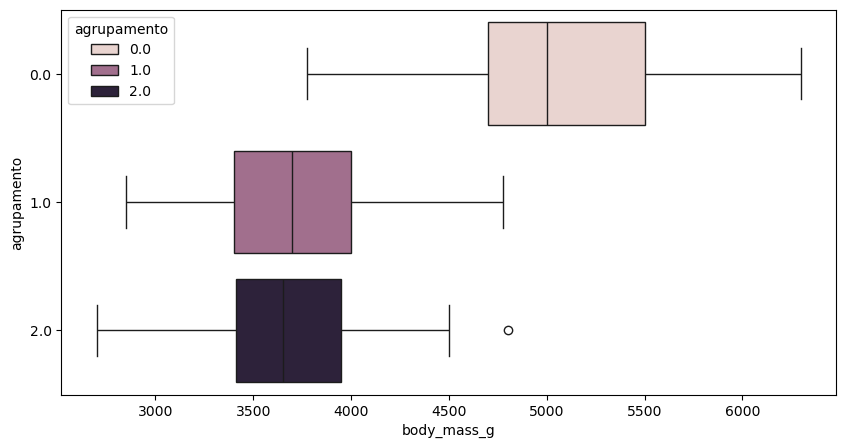

In [29]:
vars = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

for varx in vars:
    plot_box(varx)

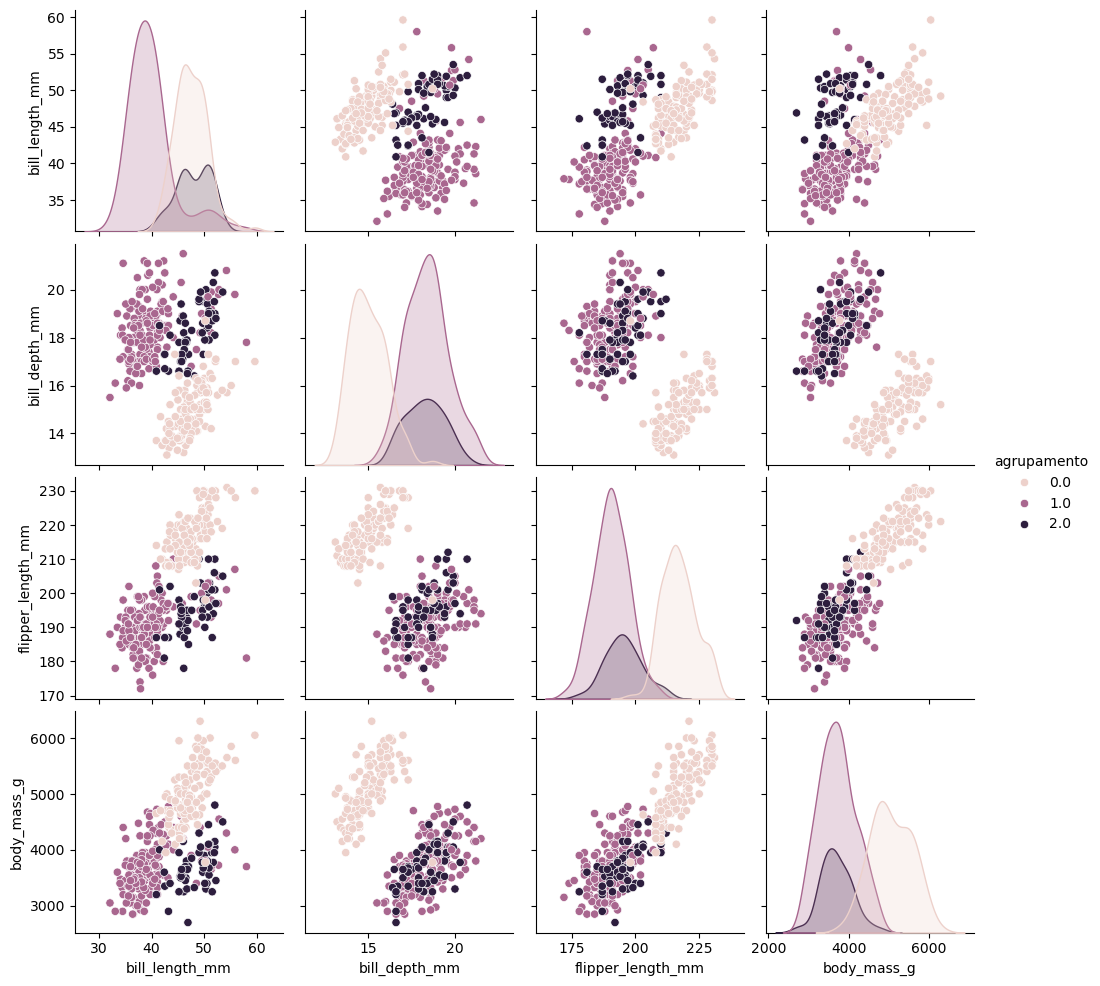

In [30]:
sns.pairplot(penguins, hue='agrupamento')
plt.show()

Como podemos notar por meio do `boxplot`, para a variável `bill_length_mm`, o grupo 0 e o grupo 2 do agrupamento possuem dados semelhantes, são praticamente redundantes nessa variável, porém são bem distintos nas demais. Para as outras três variáveis (`bill_depth_mm`, `flipper_length_mm`, `body_mass_g`), o grupo 0 possui seus dados bem separados enquanto que os grupos 1 e 2 se misturam, isso pode ser evidenciado pelo `boxplot` e pelo `pairplot`.


## 3) Alterando o agrupamento

O Dendrogarma sugere que podem haver grupos interessantes se solicitarmos mais que 3 grupos. Se quisermos testar o agrupamento com mais de 3 grupos, quantos grupos o Dendrograma te sugere? (Dica: não faça mais que 6 grupos).

- Faça o agrupamento hierárquico semelhante ao anterior, mas com o número de grupos que você escolheu.
- Analise esses agrupamentos
    - Quantos pinguins de cada espécie há em cada grupo?
    - Quantos pinguins de cada espécie machos e fêmeas há em cada grupo?
- Na sua opinião, o agrupamento capturou algum padrão natural dos dados? Qual?

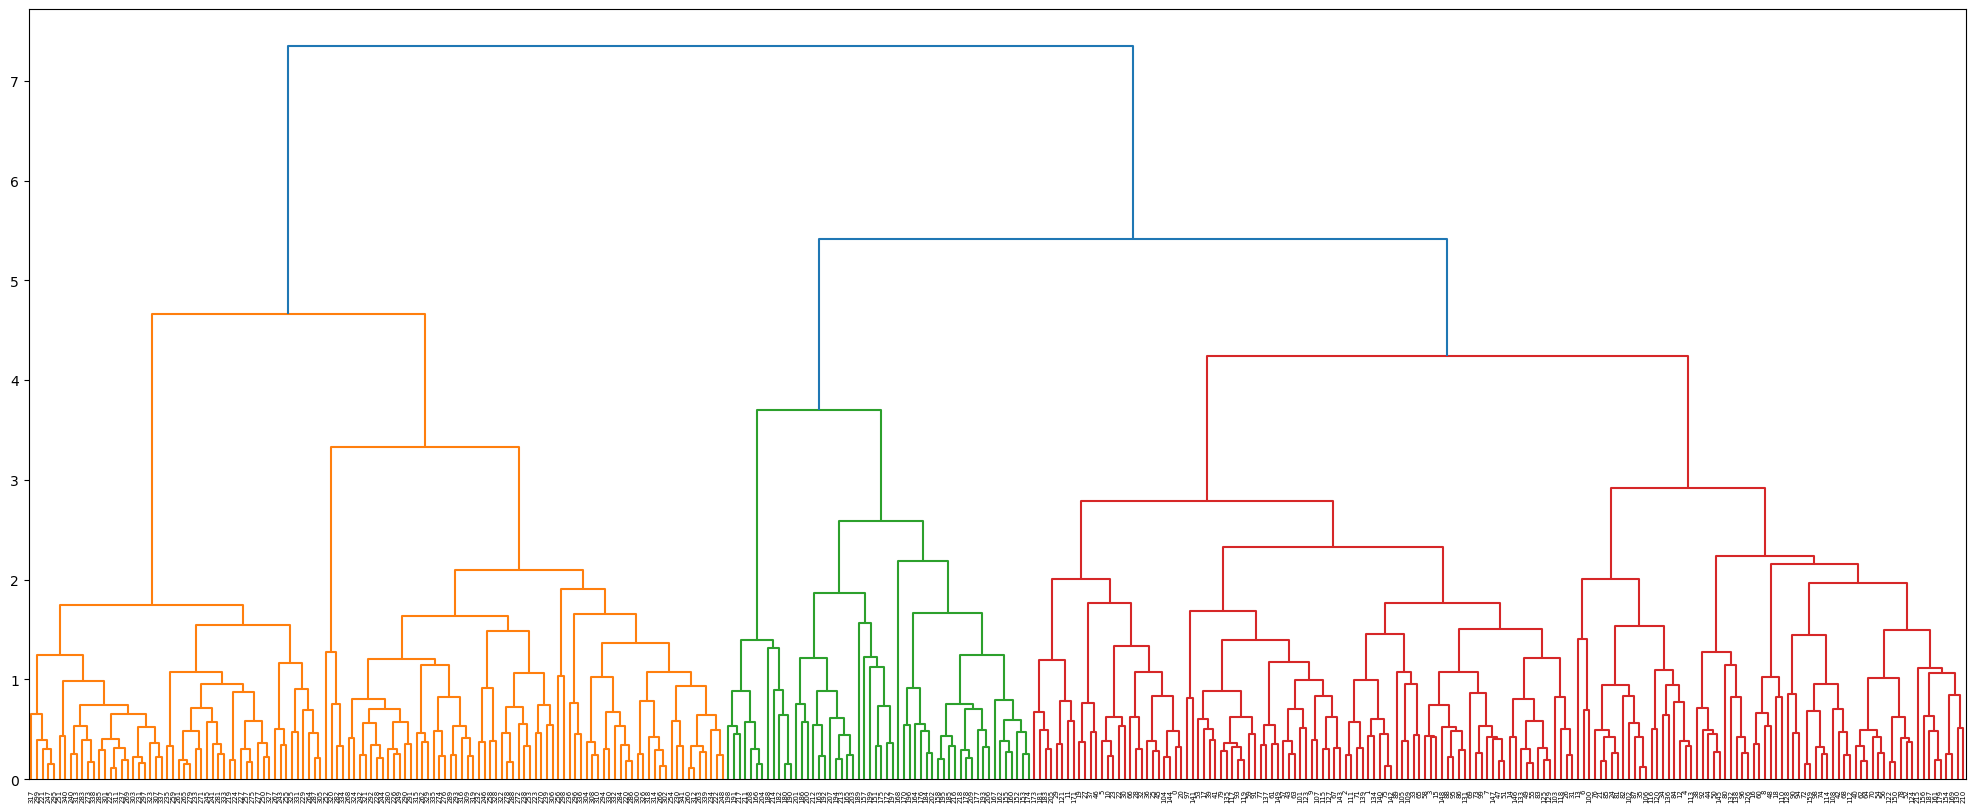

In [33]:
plt.figure(figsize=[25,10])
dendrograma = shc.dendrogram(shc.linkage(peng_pad, method='complete'))

Analisando o dendrograma me parece plausível considerar um agrupamento de até no máximo 5 grupos. Pois com esses 5 ainda teremos uma distância razoável entre os grupos e cada grupo irá possuir um número significativo de dados (vide dendrograma acima).


##### Façamos um agrupamento considerando 5 grupos

In [36]:
# Definindo o agrupamento

agrupamento_2 = AgglomerativeClustering(n_clusters=5)
agrupamento_2

AgglomerativeClustering(n_clusters=5)

In [37]:
# Utilizaremos os dados padronizados (somente as variáveis de interesse)
agrupamento_2.fit(peng_pad[peng_pad.columns[:4]])

AgglomerativeClustering(n_clusters=5)

In [38]:
# Verificando os labels
agrupamento_2.labels_

array([1, 1, 1, 1, 3, 1, 3, 1, 3, 1, 1, 1, 3, 3, 1, 1, 3, 1, 3, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 3, 1, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 1, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 1, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 1, 1, 3, 1, 3, 1, 1, 1, 3, 1, 1, 1,
       1, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 1, 1, 3, 1, 3, 1,
       3, 1, 3, 3, 3, 1, 3, 1, 1, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 1, 1, 3, 1, 3, 1, 1, 1, 1, 1, 1, 3, 1, 1, 1, 1, 3, 2, 2, 2,
       2, 2, 2, 1, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 2,
       2, 2, 2, 2, 2, 1, 2, 1, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 2, 3, 2, 2, 2, 2, 3, 2, 2, 2, 4,
       0, 4, 0, 0, 4, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 0, 4, 4,
       0, 4, 0, 4, 0, 4, 0, 0, 4, 4, 0, 0, 0, 4, 0, 4, 0, 4, 0, 4, 0, 0,
       4, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4,
       0, 4, 0, 0, 0, 0, 0, 0, 0, 4, 0, 4, 0, 4, 0,

In [39]:
# Adicionando aos dados
peng_pad['agrupamento_2'] = agrupamento_2.labels_
peng_pad.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,agrupamento,agrupamento_2
id_peng,,,,,,
0,-0.884499,0.785449,-1.418347,-0.564142,1,1
1,-0.811126,0.126188,-1.062250,-0.501703,1,1
2,-0.664380,0.430462,-0.421277,-1.188532,1,1
3,-1.324737,1.089724,-0.563715,-0.938776,1,1
4,-0.847812,1.748985,-0.777373,-0.689020,1,3


In [40]:
# Adicionando também aos dados originais
penguins = penguins.merge(peng_pad['agrupamento_2'], how='left', on='id_peng')

In [41]:
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,agrupamento,agrupamento_2
id_peng,,,,,,,,,
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male,1.0,1.0
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female,1.0,1.0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female,1.0,1.0
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,1.0,1.0
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female,1.0,3.0


##### Avaliando a crosstab do agrupamento_2 com a species


Aqui podemos verificar quantos pinguins de cada espécie há em cada grupo.

In [43]:
df_species = pd.crosstab(penguins.species, penguins.agrupamento_2)
df_species

agrupamento_2,0.0,1.0,2.0,3.0,4.0
species,,,,,
Adelie,0,97,1,54,0
Chinstrap,0,8,56,3,1
Gentoo,71,0,0,0,51


Como podemos notar, os grupos 0.0 e 4.0 do agrupamento descrevem e separam muito bem a espécie Gentoo das demais. Os grupos 1.0 e 3.0 descrevem bem a espécie Adelie, apesar de haver dado da espécie Chinstrap. E, por fim, o grupo 2.0 descreve bem os dados associados à espécie Chinstrap. 

Façamos uma visualização gráfica dessa distribuição.

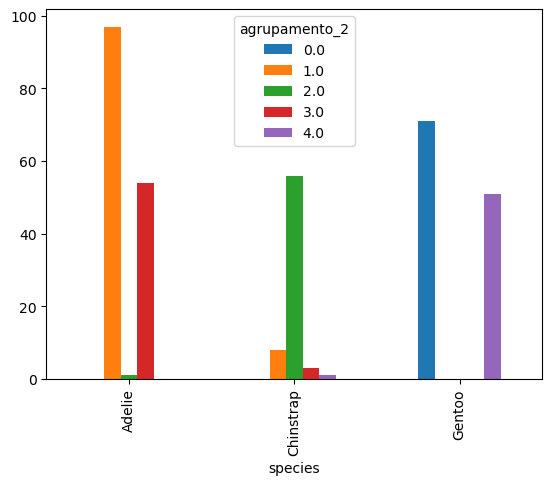

In [44]:
# Visualização gráfica
df_species.plot.bar();

##### Fazendo a contagem de quantos pinguins de cada espécie e seu respectivo sexo há em cada grupo do agrupamento

In [46]:
# Organizando os dados

df = penguins.groupby(['species', 'sex', 'agrupamento_2'])['agrupamento_2'].count().unstack()
df = df.fillna(0)
df

agrupamento_2      0.0   1.0   2.0   3.0   4.0
species   sex                                 
Adelie    Female   0.0  24.0   0.0  49.0   0.0
          Male     0.0  68.0   1.0   4.0   0.0
Chinstrap Female   0.0   1.0  32.0   0.0   1.0
          Male     0.0   7.0  24.0   3.0   0.0
Gentoo    Female  50.0   0.0   0.0   0.0   7.0
          Male    16.0   0.0   0.0   0.0  44.0

Como podemos notar as espécies que estão distribuídas em dois grupos, como Gentoo nos grupos 0.0 e 4.0 e Adelie nos grupos 1.0 e 3.0, tem os sexos dos indivíduos razoavelmente bem definidos. O grupo 0.0 é capaz de definir ~ 87% dos pinguins fêmeas da espécie Gentoo e o grupo 4.0 ~73% dos pinguins machos dessa mesma espécie. Algo semelhante acontece para a espécie Adelie, em que os 1.0 e 3.0 conseguem descrever majoritariamente o sexo dos pinguins machos e fêmeas, respectivamente. O grupo 2.0 captura a informação da espécie do pinguim Chinstrap, mas não é capaz, isoladamente, de defini-lo por seu sexo (talvez, para esse fim, fosse necessária criar mais um grupo).

É claro, devido às demais características e a semelhança entre os pinguins, os grupos não definem a variável com precisão de 100%, isso indicaria um overfitting do modelo.

Façamos uma visualização gráfica da distribuição dos pinguins por espécie e sexo nos grupos.


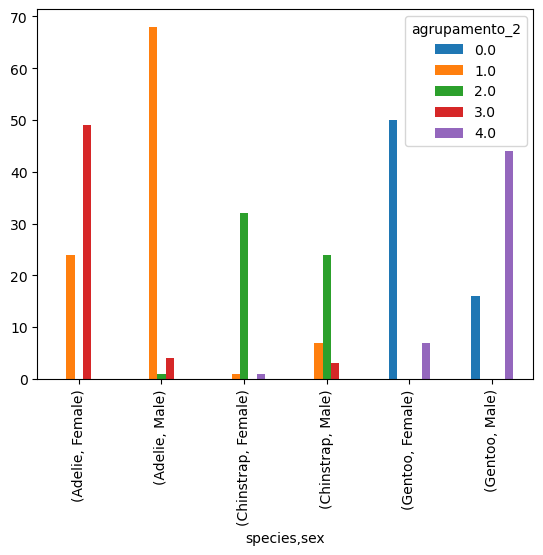

In [47]:
# Gerando uma visualização gráfica

df.plot.bar();